# Q-Learning

In this Lab, we will implement Q-learning for classical model free RL control

## The MDP

We will implement the Cliff environment. The task is to reach the goal state <b>G</b>, starting from initial state <b>S</b>, without falling into the cliff. 

The map of the MDP is the following:

        S C C C C C C C C C C G
        N N N N N N N N N N N N
        N N N N N N N N N N N N
        N N N N N N N N N N N N
        
 where S == starting state, G == goal state, N == normal state

# Define your env.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class GridWithCliff:
    def __init__(self, goal_position: tuple, cliff_positions: list,
                       normal_reward: int, goal_reward: int, cliff_reward: int):

        self.goal_position = goal_position
        self.cliff_positions = cliff_positions
        self.grid = np.arange(0, 48).reshape(4, 12)
        self.env_rewards = np.zeros(self.grid.shape) + normal_reward
        self.env_rewards[goal_position] = goal_reward
        self.env_rewards[0, cliff_positions] = cliff_reward

        self.possible_actions = np.arange(0, 4) # 0: up, 1: down, 2: left, 3: right

    def reset(self):
        return (0, 0)

    def step(self, action: int, current_state: tuple):
        assert action in self.possible_actions
        assert current_state[0] <= self.grid.shape[0] and current_state[1] <= self.grid.shape[1]

        next_state = None
        if action == 0: #up
            if current_state[0] == 0:
                next_state = current_state
            else:
                next_state = (current_state[0]-1, current_state[1])

        elif action == 1: #down
            if current_state[0] == 3:
                next_state = current_state
            else:
                next_state = (current_state[0]+1, current_state[1])

        elif action == 2: #left
            if current_state[1] == 0:
                next_state = current_state
            else:
                next_state = (current_state[0], current_state[1]-1)

        elif action == 3: #right
            if current_state[1] == 11:
                next_state = current_state
            else:
                next_state = (current_state[0], current_state[1]+1)

        reward = self.get_reward(next_state)
        if next_state == self.goal_position or \
                (next_state[0] == 0 and next_state[1] in self.cliff_positions):
            done = True
        else:
            done = False

        return next_state, reward, done

    def get_reward(self, state: tuple):
        return self.env_rewards[state]

# Define  Q-learning agent


You will write code for the collection policy (used in data collection). You will define two collection policies: eps-greedy and uniform policy. You will also write the learn method in which the agent interacts with the environemnt for num_episodes and apply Q-learning update rule for the Q-values.

In [16]:
class QlearningAgent:
    def __init__(self, num_states: int, num_actions: int, gamma: float,
                 eps_start: float, eps_end: float, eps_decay: bool,
                 alpha: float, num_episodes: int, policy: str):
        self.num_states = num_states
        self.num_actions = num_actions
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.alpha = alpha
        self.num_episodes = num_episodes
        self.policy = policy
        
        self.q_fun = np.zeros((num_states,num_actions))
        self.pi = np.zeros(num_states)
        
    def get_action(self, env, state_index:int, eps: float):
        assert self.policy in ['eps-greedy', 'uniform']
        
        if self.policy == 'eps-greedy':
            r = np.random.rand()
            if r >= eps:
                a = np.argmax(self.q_fun[state_index, :])
            else:
                index = np.random.randint(0, len(env.possible_actions))
                a = env.possible_actions[index] 
                
        elif self.policy == 'uniform':
            index = np.random.randint(0, len(env.possible_actions))
            a = env.possible_actions[index]
            
        return a

    def learn(self, env: GridWithCliff):
        if self.eps_decay:
            eps_decay = (self.eps_end/self.eps_start)**(1/self.num_episodes)

        eps = self.eps_start
        avg_reward_list = []
        for episode in range(self.num_episodes):
            reward_list = []
            s = env.reset()
            while True:
                state_index = env.grid[s[0], s[1]]
                a = self.get_action(env, state_index, eps)
                ob, rew, done = env.step(a, s)
                reward_list.append(rew)
                if done:
                    target = rew
                else:
                    s_next = ob
                    next_state_index = env.grid[s_next[0], s_next[1]]
                    target = rew + gamma*np.max(self.q_fun[next_state_index, :])

                self.q_fun[state_index, a] = (1-self.alpha)*self.q_fun[state_index, a] \
                                             + self.alpha*target

                if done:
                    break
                else:
                    s = s_next
                    
            avg_reward_list.append(np.sum(reward_list))## sum not mean because it is a 0-1 reward env.

            if self.eps_decay:
                eps *= eps_decay

            ## if there is no epsilon decay,
            # stop epsilon last 10 episodes to make sure optimal policy is learned
            if self.num_episodes - episode <= 10 and not self.eps_decay:
                eps = 0

        for i in range(self.num_states):
            self.pi[i] = np.argmax(self.q_fun[i, :])

        return avg_reward_list

# Env. and main parameters

In [4]:
## Create the environment
goal_position = (0, 11)
cliff_positions = np.arange(1, 11)
normal_reward = -1
goal_reward = -1
cliff_reward = -100
env = GridWithCliff(goal_position, cliff_positions, normal_reward, goal_reward, cliff_reward)
num_states = env.grid.shape[0]*env.grid.shape[1]
num_actions = len(env.possible_actions)

In [5]:
gamma = 1
num_episodes = 500
alpha = 0.5

# no epislon decay and behavior policy is eps-greedy

In [6]:
eps_start = 0.1
eps_end = 10 ** -4
eps_decay = False ## use True or False
behave_policy = 'eps-greedy' ## use 'eps-greedy' or 'uniform'

## Q-learning
sum_rewards_runs_episodes_qlearning = []
smoothed_sum_rewards_runs_episodes_qlearning = []
optimal_policy_runs_episodes_qlearning = []
for run in range(10):
    q_learning_agent = QlearningAgent(num_states, num_actions, gamma, eps_start
                                      , eps_end, eps_decay, alpha, num_episodes, behave_policy)
    sum_reward_list_qlearning = q_learning_agent.learn(env)
    optimal_policy = q_learning_agent.pi
    ## smoothing
    smoothed_sum_rewards_q_learning = []
    for i in range(len(sum_reward_list_qlearning) - 10):
        smoothed_sum_rewards_q_learning.append(np.mean(sum_reward_list_qlearning[i:i + 10]))
    sum_rewards_runs_episodes_qlearning.append(sum_reward_list_qlearning)
    smoothed_sum_rewards_runs_episodes_qlearning.append(smoothed_sum_rewards_q_learning)
    optimal_policy_runs_episodes_qlearning.append(optimal_policy)

In [7]:
print(f'Optimal Policy via Q-learning {np.asarray(optimal_policy_runs_episodes_qlearning[0]).reshape(4, 12)}')

Optimal Policy via Q-learning [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 0.]
 [0. 0. 0. 0. 3. 3. 0. 3. 0. 3. 0. 0.]
 [1. 0. 1. 1. 3. 1. 3. 3. 1. 0. 3. 0.]]


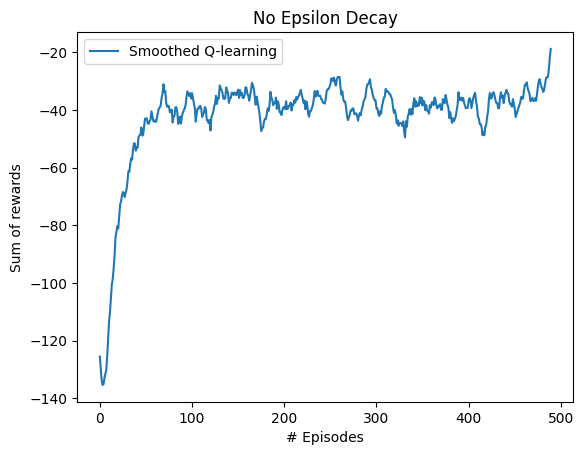

In [9]:
plt.figure()
plt.plot(np.mean(smoothed_sum_rewards_runs_episodes_qlearning, axis=0), label='Smoothed Q-learning')
plt.xlabel('# Episodes')
plt.ylabel('Sum of rewards')
plt.title('No Epsilon Decay')
plt.legend()

# enable eps_decay

In [10]:
eps_start = 0.01
eps_end = 10 ** -4
eps_decay = True ## use 'True' or 'False'
behave_policy = 'eps-greedy' ## use 'eps-greedy' or 'uniform'

## Q-learning
sum_rewards_runs_episodes_qlearning = []
smoothed_sum_rewards_runs_episodes_qlearning = []
optimal_policy_runs_episodes_qlearning = []
for run in range(10):
    q_learning_agent = QlearningAgent(num_states, num_actions, gamma, eps_start
                                      , eps_end, eps_decay, alpha, num_episodes, behave_policy)
    sum_reward_list_qlearning = q_learning_agent.learn(env)
    optimal_policy = q_learning_agent.pi
    ## smoothing
    smoothed_sum_rewards_q_learning = []
    for i in range(len(sum_reward_list_qlearning) - 10):
        smoothed_sum_rewards_q_learning.append(np.mean(sum_reward_list_qlearning[i:i + 10]))
    sum_rewards_runs_episodes_qlearning.append(sum_reward_list_qlearning)
    smoothed_sum_rewards_runs_episodes_qlearning.append(smoothed_sum_rewards_q_learning)
    optimal_policy_runs_episodes_qlearning.append(optimal_policy)

In [11]:
print(f'Optimal Policy via Q-learning {np.asarray(optimal_policy_runs_episodes_qlearning[0]).reshape(4, 12)}')

Optimal Policy via Q-learning [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 0.]
 [1. 3. 0. 3. 3. 3. 3. 2. 3. 0. 0. 0.]
 [1. 3. 3. 3. 3. 2. 1. 2. 0. 1. 3. 0.]]


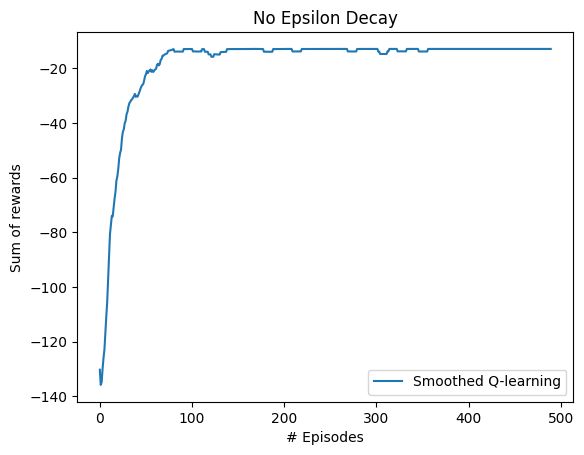

In [12]:
plt.figure()
plt.plot(np.mean(smoothed_sum_rewards_runs_episodes_qlearning, axis=0), label='Smoothed Q-learning')
plt.xlabel('# Episodes')
plt.ylabel('Sum of rewards')
plt.title('No Epsilon Decay')
plt.legend()

# Now repeat the above with uniform policy 

In [13]:
eps_start = 0.01
eps_end = 10 ** -4
eps_decay = True ## use 'True' or 'False'
behave_policy = 'uniform' ## use 'eps-greedy' or 'uniform'

## Q-learning
sum_rewards_runs_episodes_qlearning = []
smoothed_sum_rewards_runs_episodes_qlearning = []
optimal_policy_runs_episodes_qlearning = []
for run in range(10):
    q_learning_agent = QlearningAgent(num_states, num_actions, gamma, eps_start
                                      , eps_end, eps_decay, alpha, num_episodes, behave_policy)
    sum_reward_list_qlearning = q_learning_agent.learn(env)
    optimal_policy = q_learning_agent.pi
    ## smoothing
    smoothed_sum_rewards_q_learning = []
    for i in range(len(sum_reward_list_qlearning) - 10):
        smoothed_sum_rewards_q_learning.append(np.mean(sum_reward_list_qlearning[i:i + 10]))
    sum_rewards_runs_episodes_qlearning.append(sum_reward_list_qlearning)
    smoothed_sum_rewards_runs_episodes_qlearning.append(smoothed_sum_rewards_q_learning)
    optimal_policy_runs_episodes_qlearning.append(optimal_policy)

In [14]:
print(f'Optimal Policy via Q-learning {np.asarray(optimal_policy_runs_episodes_qlearning[0]).reshape(4, 12)}')

Optimal Policy via Q-learning [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [3. 3. 3. 3. 3. 3. 3. 3. 2. 3. 2. 1.]
 [3. 3. 3. 3. 3. 3. 0. 0. 0. 0. 2. 1.]
 [3. 3. 3. 3. 3. 3. 1. 0. 3. 3. 3. 0.]]


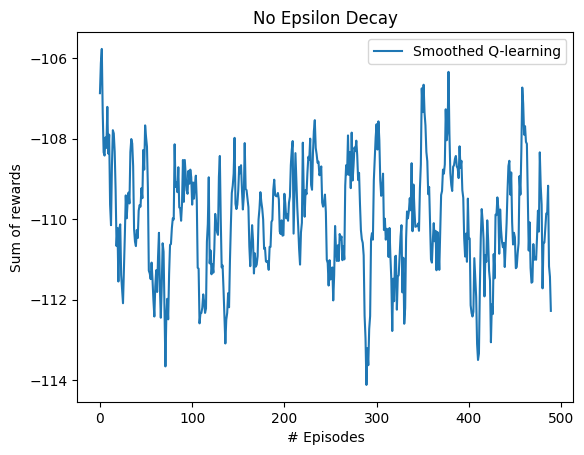

In [15]:
plt.figure()
plt.plot(np.mean(smoothed_sum_rewards_runs_episodes_qlearning, axis=0), label='Smoothed Q-learning')
plt.xlabel('# Episodes')
plt.ylabel('Sum of rewards')
plt.title('No Epsilon Decay')
plt.legend()